# Dubins car — Reach-Avoid MPC robustness under additive position disturbances

First section is identical to the original with full trajectory simulation. Second section adds disturbance.

**Disturbance model (plant-side only, controller stays nominal):**
```
ẋ₁ = v·cos(θ) + d₁,   ẋ₂ = v·sin(θ) + d₂,   θ̇ = u₁,   v̇ = u₂
d₁, d₂ ~ Uniform[-ε, ε]  (resampled each MPC step)
```

| Level    | ε (m/s) | fraction of drift |
|----------|:-------:|:-----------------:|
| Nominal  | 0.00    | 0%                |
| Mild     | 0.10    | ~20%              |
| Moderate | 0.30    | ~60%              |
| Strong   | 0.50    | ~100%             |

In [1]:
import sys, os
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, ROOT)

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import casadi as ca
from scipy.integrate import solve_ivp
from joblib import Parallel, delayed

from sop_bounded_control_dubins_car_result_20260316_211504 import (
    u_opt, certificate_opt, k1_opt
)
u_opt           = sp.Matrix(u_opt)
k1_opt          = sp.Matrix(k1_opt)

x1, x2, th, v = sp.symbols('x1 x2 th v')
y1, y2         = sp.symbols('y1 y2')
state_vars     = [x1, x2, th, v]

f_sym = sp.Matrix([v*sp.cos(th), v*sp.sin(th), 0, 0])
g_sym = sp.Matrix([[0,0],[0,0],[1,0],[0,1]])
hx    = sp.Matrix([x1, x2])

h_raw        = -(y1**4 + y2**4 - 16)*(y1**4 + y2**4 - 4)
target_set_y = (y2 - 0)**2 + (2*(y1 + 1.7))**2 - 0.4
alpha        = 1e-3*(-target_set_y + 300)
safe_set_y   = alpha * h_raw
safe_set_x   = safe_set_y.subs({y1: hx[0], y2: hx[1]})
target_set_x = target_set_y.subs({y1: hx[0], y2: hx[1]})

certificate_func  = sp.lambdify(state_vars, certificate_opt, 'numpy')
safe_set_y_func   = sp.lambdify([y1, y2], safe_set_y, 'numpy')
target_set_y_func = sp.lambdify([y1, y2], target_set_y, 'numpy')
safe_set_x_func   = sp.lambdify(state_vars, safe_set_x, 'numpy')
target_set_x_func = sp.lambdify(state_vars, target_set_x, 'numpy')
hx_func           = sp.lambdify(state_vars, hx, 'numpy')

print('Certificate symbols:', certificate_opt.free_symbols)
print('u_opt symbols:', u_opt[0].free_symbols)

Certificate symbols: {v, x1, th, x2}
u_opt symbols: {v, th, x1, x2}


In [2]:
# ── SymPy → CasADi converter (identical to original) ─────────────────────────
def sympy2casadi(expr, sym_map):
    if isinstance(expr, (sp.Integer, sp.Float, sp.Rational,
                         sp.core.numbers.NegativeOne, sp.core.numbers.Half,
                         sp.core.numbers.One, sp.core.numbers.Zero, sp.core.numbers.Pi)):
        return float(expr)
    elif isinstance(expr, sp.Symbol): return sym_map[expr]
    elif isinstance(expr, sp.Add):    return sum(sympy2casadi(a, sym_map) for a in expr.args)
    elif isinstance(expr, sp.Mul):
        r = 1.0
        for a in expr.args: r = r * sympy2casadi(a, sym_map)
        return r
    elif isinstance(expr, sp.Pow):    return sympy2casadi(expr.args[0], sym_map)**sympy2casadi(expr.args[1], sym_map)
    elif isinstance(expr, sp.sin):    return ca.sin(sympy2casadi(expr.args[0], sym_map))
    elif isinstance(expr, sp.cos):    return ca.cos(sympy2casadi(expr.args[0], sym_map))
    elif isinstance(expr, sp.Number): return float(expr)
    else: raise ValueError(f'Unsupported sympy type: {type(expr)}  --  {expr}')

ca_x1 = ca.SX.sym('x1'); ca_x2 = ca.SX.sym('x2')
ca_th = ca.SX.sym('th'); ca_v  = ca.SX.sym('v')
sym_map = {x1: ca_x1, x2: ca_x2, th: ca_th, v: ca_v}

cert_ca_expr  = sympy2casadi(certificate_opt, sym_map)
safe_ca_expr  = sympy2casadi(safe_set_x, sym_map)
cert_ca_f     = ca.Function('cert', [ca_x1, ca_x2, ca_th, ca_v], [cert_ca_expr])
safe_ca_f_raw = ca.Function('safe', [ca_x1, ca_x2, ca_th, ca_v], [safe_ca_expr])

def cert_vec(xv): return cert_ca_f(xv[0], xv[1], xv[2], xv[3])
def safe_vec(xv): return safe_ca_f_raw(xv[0], xv[1], xv[2], xv[3])

test_x = np.array([0.5, 0.5, 3.5, 0.3])
v_sp = float(certificate_opt.subs(dict(zip(state_vars, test_x))))
v_ca = float(cert_ca_f(*test_x))
assert abs(v_sp - v_ca) < 1e-4, 'Conversion mismatch!'
print('Conversions verified OK.')

Conversions verified OK.


In [ ]:
# ── RA-MPC formulation (terminal: V(x_N)>=0) ── IDENTICAL TO ORIGINAL ─────────
# max_iter set to 600 to match sampling_sweep notebook (consistent solver settings)
dt_mpc = 0.05; N_hor = 25; u1_max = 5.0; u2_max = 5.0
TARGET_POS = np.array([-1.7, 0.0])

xc = ca.SX.sym('x', 4); uc = ca.SX.sym('u', 2)
fc = ca.vertcat(xc[3]*ca.cos(xc[2]), xc[3]*ca.sin(xc[2]), uc[0], uc[1])
rhs_ca  = ca.Function('f', [xc, uc], [fc])
k1_     = rhs_ca(xc, uc)
k2_     = rhs_ca(xc + dt_mpc/2*k1_, uc)
k3_     = rhs_ca(xc + dt_mpc/2*k2_, uc)
k4_     = rhs_ca(xc + dt_mpc*k3_, uc)
F_disc  = ca.Function('F_disc', [xc, uc], [xc + (dt_mpc/6)*(k1_ + 2*k2_ + 2*k3_ + k4_)])

def h_ca(xv): return ca.vertcat(xv[0], xv[1])

_IPOPT_OPTS = {
    'ipopt.print_level': 0, 'print_time': 0,
    'ipopt.max_iter': 600,    # standardised to 600 across all experiment notebooks
    'ipopt.tol': 1e-4, 'ipopt.acceptable_tol': 1e-3,
}

def solve_mpc(x0_val, U_warm=None):
    opti = ca.Opti()
    X_var = opti.variable(4, N_hor+1); U_var = opti.variable(2, N_hor)
    x0_np = np.asarray(x0_val, dtype=float).flatten()
    opti.subject_to(X_var[:, 0] == x0_np)
    for k in range(N_hor):
        opti.subject_to(X_var[:, k+1] == F_disc(X_var[:, k], U_var[:, k]))
        opti.subject_to(safe_vec(X_var[:, k]) >= 0)
    opti.subject_to(safe_vec(X_var[:, N_hor]) >= 0)
    opti.subject_to(cert_vec(X_var[:, N_hor]) >= 0)
    opti.subject_to(opti.bounded(-u1_max, U_var[0, :], u1_max))
    opti.subject_to(opti.bounded(-u2_max, U_var[1, :], u2_max))
    tgt = ca.DM(TARGET_POS)
    Q_y  = ca.DM([[5.0,0],[0,5.0]]); Qf_y = ca.DM([[80.,0],[0,80.]]); R_u = ca.DM([[.05,0],[0,.05]])
    cost = 0
    for k in range(N_hor):
        dy = h_ca(X_var[:, k]) - tgt
        cost += dy.T@Q_y@dy + U_var[:, k].T@R_u@U_var[:, k]
    dy_N = h_ca(X_var[:, N_hor]) - tgt
    cost += dy_N.T@Qf_y@dy_N
    opti.minimize(cost)
    if U_warm is not None:
        U_ws = np.hstack([U_warm[:, 1:], U_warm[:, -1:]])
        X_ws = np.zeros((4, N_hor+1)); X_ws[:, 0] = x0_np
        for k in range(N_hor):
            xk, uk = X_ws[:, k], U_ws[:, k]
            X_ws[:, k+1] = xk + dt_mpc*np.array(
                [xk[3]*np.cos(xk[2]), xk[3]*np.sin(xk[2]), uk[0], uk[1]])
        opti.set_initial(X_var, X_ws); opti.set_initial(U_var, U_ws)
    else:
        tgt_full = np.array([TARGET_POS[0], TARGET_POS[1], x0_np[2], 0.0])
        X_ws = np.array([(1-k/N_hor)*x0_np + (k/N_hor)*tgt_full for k in range(N_hor+1)]).T
        opti.set_initial(X_var, X_ws); opti.set_initial(U_var, 0)
    opti.solver('ipopt', _IPOPT_OPTS)
    try:
        sol = opti.solve(); return True, sol.value(U_var)
    except Exception: return False, None

print(f'RA-MPC: N_hor={N_hor}, dt={dt_mpc}s, terminal: V(x_N)>=0')
print('max_iter=600 (standardised across all experiment notebooks)')

In [4]:
# ── Sample + RA-MPC feasibility check ── IDENTICAL TO ORIGINAL ────────────────
N_samples = 1000
np.random.seed(42)
lower_bound = np.array([-2.0, -2.0, 2*np.pi/3, -1.0])
upper_bound = np.array([ 2.0,  2.0, 4*np.pi/3,  1.0])
x_samples = np.random.rand(4, N_samples)*(upper_bound-lower_bound).reshape(-1,1) + lower_bound.reshape(-1,1)

safe_vals   = np.atleast_1d(np.squeeze(safe_set_x_func(*x_samples)))
target_vals = np.atleast_1d(np.squeeze(target_set_x_func(*x_samples)))
candidate_mask = (safe_vals >= 0) & (target_vals > 0)
candidate_idx  = np.where(candidate_mask)[0][:300]
print(f'Total samples : {N_samples}')
print(f'Candidates (safe & outside target): {len(candidate_idx)}')

def _check_one(idx):
    ok, _ = solve_mpc(x_samples[:, idx])
    return idx, ok

print(f'\nChecking RA-MPC feasibility ({len(candidate_idx)} candidates, '
      f'N_hor={N_hor}, dt={dt_mpc}s, terminal: V(x_N)\u22650) ...')
results = Parallel(n_jobs=-1, prefer='processes', verbose=5)(
    delayed(_check_one)(idx) for idx in candidate_idx
)
mpc_feasible_idx   = np.array([idx for idx, ok in results if ok])
mpc_infeasible_idx = np.array([idx for idx, ok in results if not ok])
n_c = len(candidate_idx)
print(f'\nRA-MPC feasible:   {len(mpc_feasible_idx):3d} / {n_c}  ({100*len(mpc_feasible_idx)/n_c:.1f}%)')
print(f'RA-MPC infeasible: {len(mpc_infeasible_idx):3d} / {n_c}  ({100*len(mpc_infeasible_idx)/n_c:.1f}%)')

Total samples : 1000
Candidates (safe & outside target): 300

Checking RA-MPC feasibility (300 candidates, N_hor=25, dt=0.05s, terminal: V(x_N)≥0) ...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:    3.2s
[Parallel(n_jobs=-1)]: Done 138 tasks      | elapsed:    6.2s
[Parallel(n_jobs=-1)]: Done 264 tasks      | elapsed:   11.8s



RA-MPC feasible:   288 / 300  (96.0%)
RA-MPC infeasible:  12 / 300  (4.0%)


[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:   13.9s finished


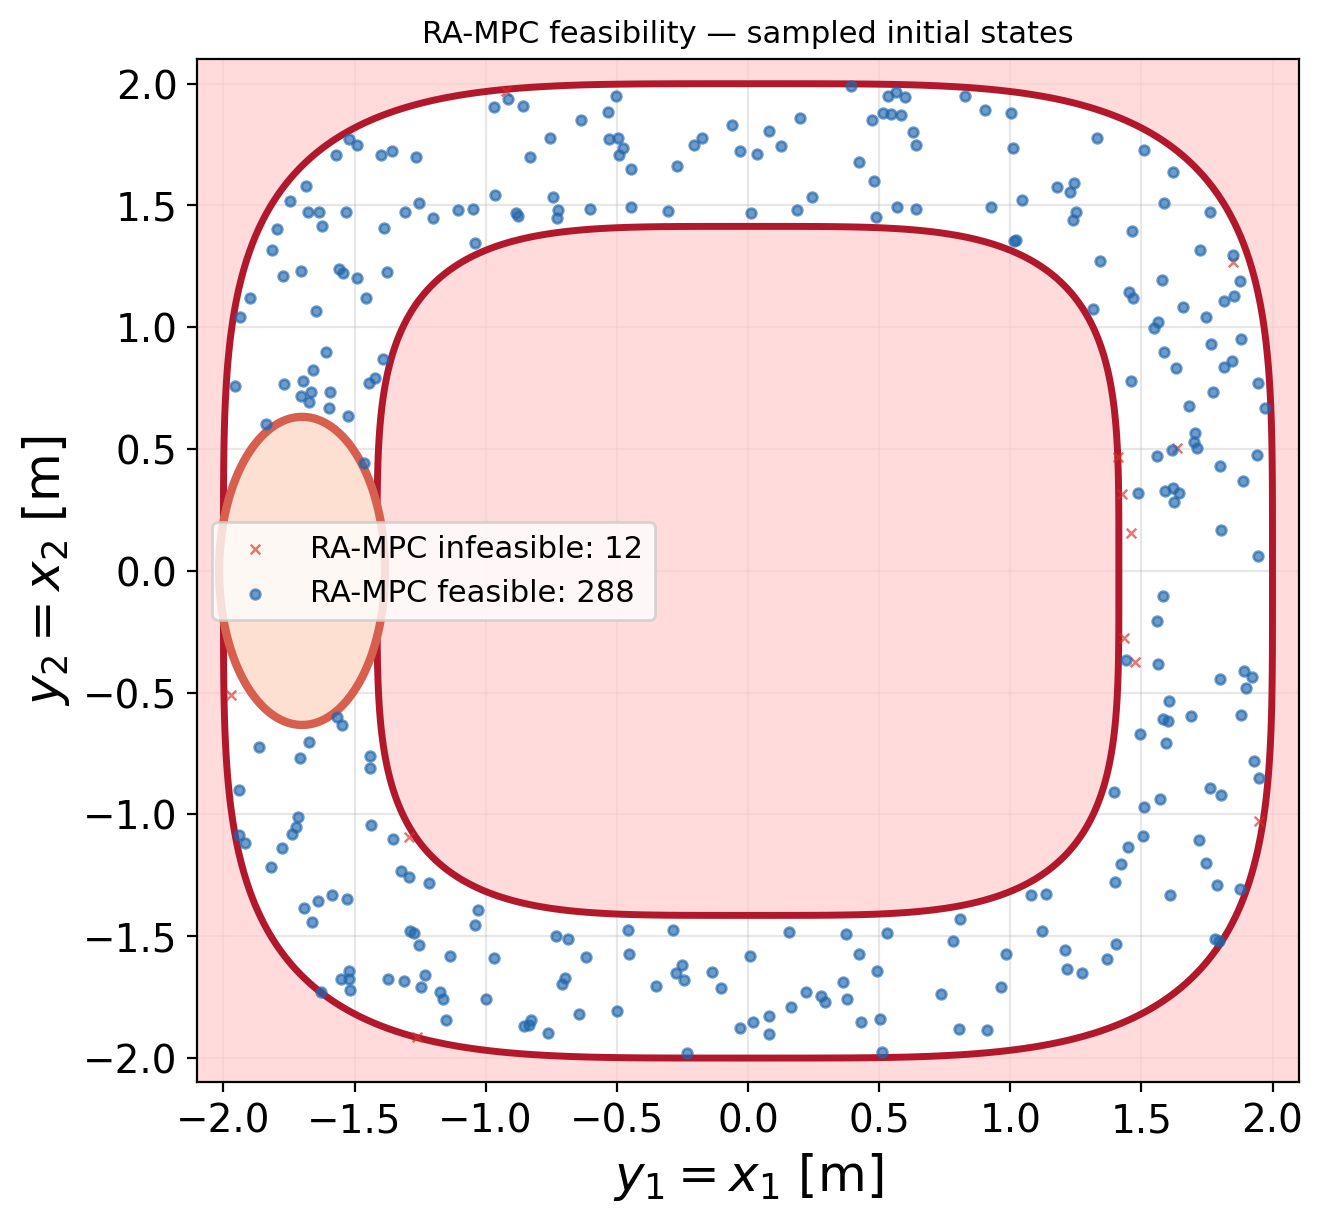

In [5]:
# ── Visualise RA-MPC feasible/infeasible states ── ORIGINAL PLOT ──────────────
from functional import BetterColor

y_feasible   = np.array(hx_func(*x_samples[:, mpc_feasible_idx])).reshape(2,-1)
y_infeasible = np.array(hx_func(*x_samples[:, mpc_infeasible_idx])).reshape(2,-1)

n_grid = 400
y1_g = np.linspace(-2.1, 2.1, n_grid); y2_g = np.linspace(-2.1, 2.1, n_grid)
Y1, Y2 = np.meshgrid(y1_g, y2_g)
Z_safe   = safe_set_y_func(Y1, Y2)
Z_target = target_set_y_func(Y1, Y2)

px_fig = 1/plt.rcParams['figure.dpi']
fig, ax = plt.subplots(figsize=(650*px_fig, 600*px_fig), layout='constrained'); fig.set_dpi(200)

ax.contourf(Y1, Y2, Z_safe,   levels=[-np.inf, 0], colors=['#ffcccc'], alpha=0.7, zorder=2)
ax.contour( Y1, Y2, Z_safe,   levels=[0], colors=['#b2182b'], linewidths=2.5, zorder=3)
ax.contourf(Y1, Y2, Z_target, levels=[-np.inf, 0], colors=['#fee0d2'], alpha=1.0, zorder=4)
ax.contour( Y1, Y2, Z_target, levels=[0], colors=['#d6604d'], linewidths=3, zorder=5)
ax.scatter(y_infeasible[0], y_infeasible[1], s=12, color='#d73027', alpha=0.65, marker='x',
           linewidths=0.9, label=f'RA-MPC infeasible: {len(mpc_infeasible_idx)}', zorder=9)
ax.scatter(y_feasible[0],   y_feasible[1],   s=12, color='#2166ac', alpha=0.65, marker='o',
           label=f'RA-MPC feasible: {len(mpc_feasible_idx)}', zorder=10)

ax.set_xlabel('$y_1 = x_1$ [m]', fontsize=22-4); ax.set_ylabel('$y_2 = x_2$ [m]', fontsize=22-4)
ax.xaxis.set_tick_params(labelsize=14); ax.yaxis.set_tick_params(labelsize=14)
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
ax.set_title('RA-MPC feasibility — sampled initial states', fontsize=11)
plt.show()

In [6]:
# ── NOMINAL RA-MPC simulation — uses ALL RA-MPC-feasible ICs ─────────────────
T_max = 10.0; T_min = 1.1; phi_tol = 0.05

def simulate_ra_mpc_traj(x0):
    x = np.asarray(x0, dtype=float).copy()
    xs, ts = [x.copy()], [0.0]
    t = 0.0; U_prev = None

    while t < T_max - 1e-9:
        if float(np.squeeze(target_set_x_func(*x))) <= 0: break
        ok, U_opt = solve_mpc(x, U_warm=U_prev)
        if not ok: break
        u0 = np.array(U_opt[:, 0]).flatten(); U_prev = U_opt

        def rhs(_, x_):
            return [x_[3]*np.cos(x_[2]), x_[3]*np.sin(x_[2]),
                    float(u0[0]), float(u0[1])]

        sol = solve_ivp(rhs, [t, t+dt_mpc], x, method='DOP853',
                        rtol=1e-8, atol=1e-10, max_step=dt_mpc/10)
        if not np.all(np.isfinite(sol.y)): break
        x = sol.y[:, -1]; t += dt_mpc
        xs.append(x.copy()); ts.append(t)

    ts = np.array(ts); xs = np.array(xs)
    ys = np.array(hx_func(*xs.T)).reshape(2, -1).T
    return ts, xs, ys

# Use ALL RA-MPC-feasible ICs (consistent with paper's 300-candidate analysis)
N_sim_try = len(mpc_feasible_idx)   # up to 288 for RA-MPC
x_sim     = x_samples[:, mpc_feasible_idx]

print(f'Simulating {N_sim_try} nominal trajectories (all RA-MPC-feasible ICs) ...')
raw = []
for i in range(N_sim_try):
    print(f'  [{i+1:3d}/{N_sim_try}] ', end='', flush=True)
    res = simulate_ra_mpc_traj(x_sim[:, i])
    raw.append(res)
    tt, tx, _ = res
    phi_f = float(np.squeeze(target_set_x_func(*tx[-1])))
    print(f'T={tt[-1]:.2f}s  {"REACHED" if phi_f<=0 else f"phi={phi_f:.4f}"}')

traj_t = [r[0] for r in raw]
traj_x = [r[1] for r in raw]
traj_y = [r[2] for r in raw]

n_nom_ok = sum(1 for tt, tx, _ in zip(traj_t, traj_x, traj_y)
               if float(np.squeeze(target_set_x_func(*tx[-1]))) <= phi_tol)
print(f'\nNominal success: {n_nom_ok}/{N_sim_try} ({100*n_nom_ok/N_sim_try:.1f}%)')

Simulating 288 nominal trajectories (all RA-MPC-feasible ICs) ...
  [  1/288] 
******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

T=1.40s  REACHED
  [  2/288] T=1.20s  REACHED
  [  3/288] T=0.60s  REACHED
  [  4/288] T=0.50s  REACHED
  [  5/288] T=1.35s  REACHED
  [  6/288] T=0.55s  REACHED
  [  7/288] T=1.45s  REACHED
  [  8/288] T=0.90s  REACHED
  [  9/288] T=0.75s  REACHED
  [ 10/288] T=1.00s  REACHED
  [ 11/288] T=0.80s  REACHED
  [ 12/288] T=0.40s  REACHED
  [ 13/288] T=0.75s  REACHED
  [ 14/288] T=0.90s  REACHED
  [ 15/288] T=1.20s  REACHED
  [ 16/288] T=0.55s  REACHED
  [ 17/288] T=0.60s  REACHED
  [ 18/288] T=1.35s  REACHED
  [ 19/288] T=0.55s  REAC

Kept 1/288 for plot


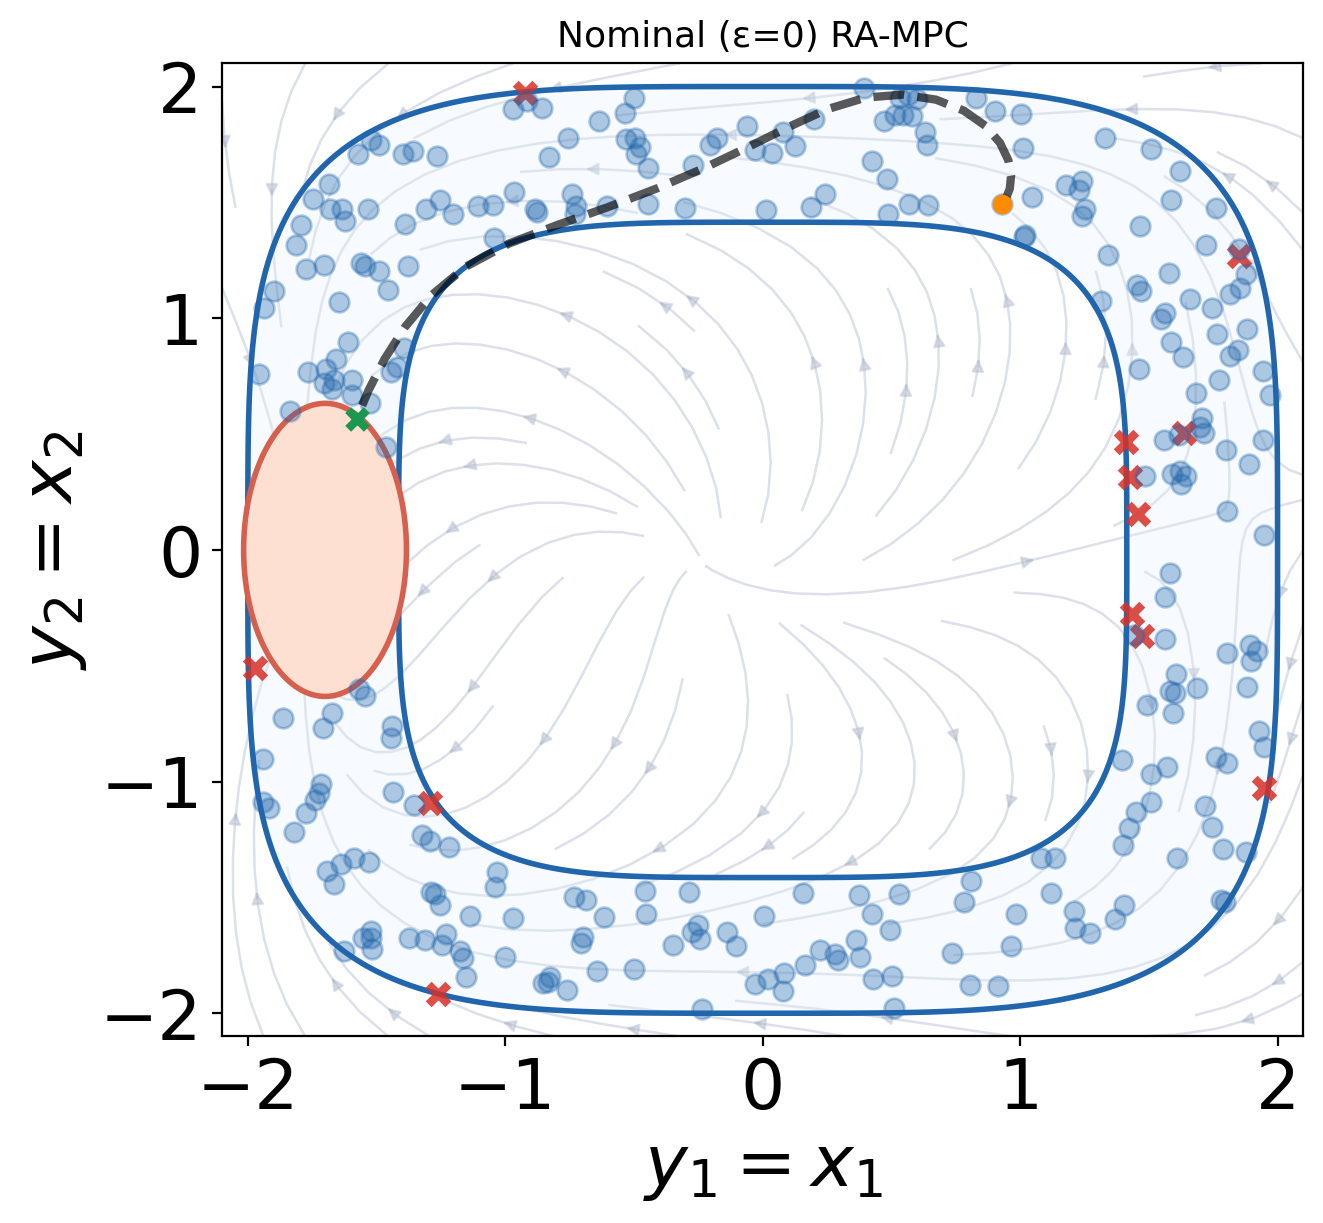

In [7]:
# ── Filter + visualise nominal trajectories + k1 vector field ── ORIGINAL PLOT
filtered = [
    (tt, tx, ty)
    for tt, tx, ty in zip(traj_t, traj_x, traj_y)
    if tt[-1] < T_max-1e-6 and tt[-1] >= T_min
    and float(np.squeeze(target_set_x_func(*tx[-1]))) <= phi_tol
][1:2]
print(f'Kept {len(filtered)}/{len(traj_t)} for plot')
traj_t_plot, traj_x_plot, traj_y_plot = zip(*filtered) if filtered else ([], [], [])

n_grid = 400
y1_g = np.linspace(-2.1, 2.1, n_grid); y2_g = np.linspace(-2.1, 2.1, n_grid)
Y1, Y2 = np.meshgrid(y1_g, y2_g)
Z_safe_y   = safe_set_y_func(Y1, Y2)
Z_target_y = target_set_y_func(Y1, Y2)

k1_func = sp.lambdify([y1, y2], list(k1_opt), 'numpy')
n_vf = 30; y1_vf = np.linspace(-2.1, 2.1, n_vf); y2_vf = np.linspace(-2.1, 2.1, n_vf)
VF_Y1, VF_Y2 = np.meshgrid(y1_vf, y2_vf)
k1_vals = np.array(k1_func(VF_Y1, VF_Y2)).squeeze()
U_k1, V_k1 = k1_vals[0], k1_vals[1]

px_fig = 1/plt.rcParams['figure.dpi']
fig, ax = plt.subplots(figsize=(650*px_fig, 600*px_fig), layout='constrained'); fig.set_dpi(200)

ax.streamplot(y1_vf, y2_vf, U_k1, V_k1, color=BetterColor.gray0(0.45),
              linewidth=0.9, density=0.9, arrowsize=0.9, zorder=1)
ax.contourf(Y1, Y2, Z_safe_y,   levels=[0, np.inf],  colors=['#e6f2ff'], alpha=0.3, zorder=1)
ax.contour( Y1, Y2, Z_safe_y,   levels=[0], colors=['#2166ac'], linewidths=2, zorder=2)
ax.contourf(Y1, Y2, Z_target_y, levels=[-np.inf, 0], colors=['#fee0d2'], alpha=1.0, zorder=3)
ax.contour( Y1, Y2, Z_target_y, levels=[0], colors=['#d6604d'], linewidths=2, zorder=4)
ax.scatter(y_infeasible[0], y_infeasible[1], s=50, color='#d73027', alpha=0.85, marker='x',
           linewidths=3, label=f'RA-MPC infeasible: {len(mpc_infeasible_idx)}', zorder=8)
ax.scatter(y_feasible[0],   y_feasible[1],   s=50, color='#2166ac', alpha=0.35, marker='o',
           label=f'RA-MPC feasible: {len(mpc_feasible_idx)}', zorder=9)

for ty in traj_y_plot:
    ax.plot(ty[:, 0], ty[:, 1], color='black', lw=3, alpha=0.65, linestyle='--', zorder=10)
    ax.scatter(ty[0, 0],  ty[0, 1],  s=45, c=[BetterColor.orange3()], marker='o', linewidths=0.4, zorder=20)
    ax.scatter(ty[-1, 0], ty[-1, 1], s=45, c=[BetterColor.green0()],  marker='x', linewidths=3.0, zorder=20)

fs = 30
ax.set_xlabel('$y_1 = x_1$', fontsize=fs-4); ax.set_ylabel('$y_2 = x_2$', fontsize=fs-4)
ax.xaxis.set_tick_params(labelsize=25); ax.yaxis.set_tick_params(labelsize=25)
ax.set_title('Nominal (\u03b5=0) RA-MPC', fontsize=13)
plt.savefig('fig_nominal_ra_mpc.png', dpi=150, bbox_inches='tight')
plt.show()

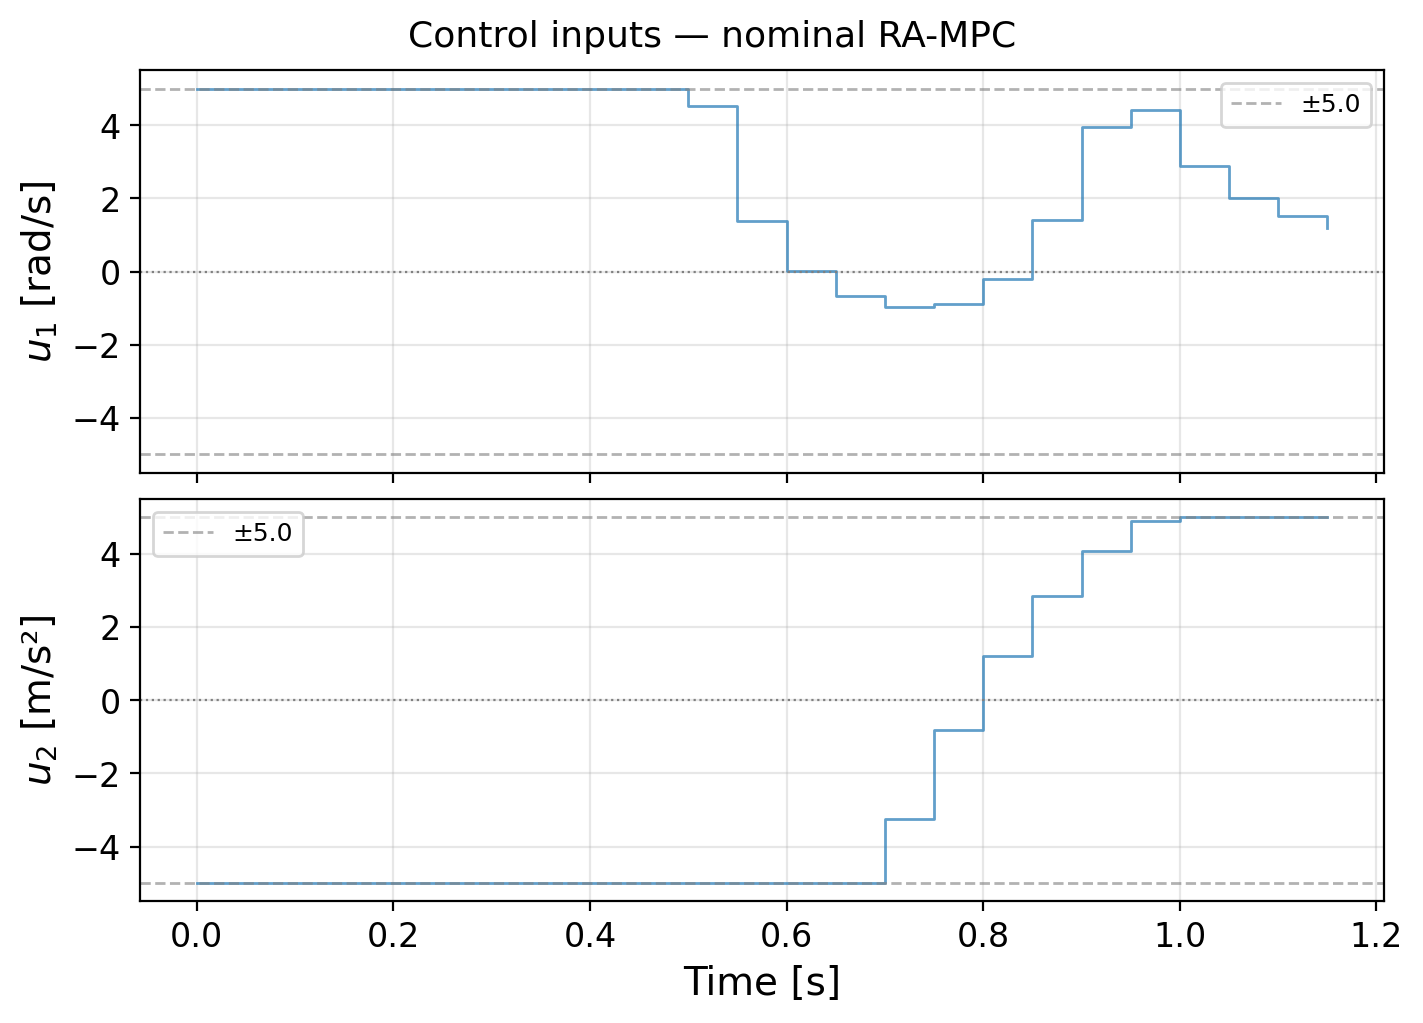

In [8]:
# ── Control inputs — nominal ── ORIGINAL PLOT ─────────────────────────────────
px_fig = 1/plt.rcParams['figure.dpi']
fig, axes = plt.subplots(2, 1, figsize=(700*px_fig, 500*px_fig), layout='constrained', sharex=True)
fig.set_dpi(200)
for tt, tx in zip(traj_t_plot, traj_x_plot):
    if len(tt) < 2: continue
    dt_arr = np.diff(tt)
    axes[0].step(tt[:-1], np.diff(tx[:, 2])/dt_arr, lw=1.0, alpha=0.7, where='post')
    axes[1].step(tt[:-1], np.diff(tx[:, 3])/dt_arr, lw=1.0, alpha=0.7, where='post')
for ax, lbl, bnd in zip(axes, ['$u_1$ [rad/s]', '$u_2$ [m/s\u00b2]'], [u1_max, u2_max]):
    ax.axhline( bnd, color='gray', lw=1.0, ls='--', alpha=0.6, label=f'\u00b1{bnd}')
    ax.axhline(-bnd, color='gray', lw=1.0, ls='--', alpha=0.6)
    ax.axhline(0,    color='gray', lw=0.8, ls=':')
    ax.set_ylabel(lbl, fontsize=14); ax.tick_params(labelsize=12)
    ax.grid(True, alpha=0.3); ax.legend(fontsize=9)
axes[1].set_xlabel('Time [s]', fontsize=14)
fig.suptitle('Control inputs — nominal RA-MPC', fontsize=13)
plt.show()

---
## Robustness Study — Additive Position Disturbance

In [9]:
import pandas as pd

LEVELS = [
    {'name': 'nominal',  'eps': 0.00},
    {'name': 'mild',     'eps': 0.10},
    {'name': 'moderate', 'eps': 0.30},
    {'name': 'strong',   'eps': 0.50},
]
DIST_SEED = 123

def simulate_ra_mpc_perturbed(x0, eps_pos, rng):
    """
    RA-MPC on perturbed plant. Controller is nominal.
    Only change vs simulate_ra_mpc_traj: d₁, d₂ added to position channels.
    """
    x = np.asarray(x0, dtype=float).copy()
    xs, ts = [x.copy()], [0.0]
    t = 0.0; U_prev = None
    n_infeasible = 0; control_effort = 0.0

    while t < T_max - 1e-9:
        if float(np.squeeze(target_set_x_func(*x))) <= 0: break
        ok, U_opt = solve_mpc(x, U_warm=U_prev)
        if not ok:
            n_infeasible += 1; break
        u0 = np.array(U_opt[:, 0]).flatten(); U_prev = U_opt

        d = rng.uniform(-eps_pos, eps_pos, size=2) if eps_pos > 0 else np.zeros(2)

        def rhs(_, x_):
            return [
                x_[3]*np.cos(x_[2]) + d[0],   # ← disturbance
                x_[3]*np.sin(x_[2]) + d[1],   # ← disturbance
                float(u0[0]),
                float(u0[1]),
            ]

        sol = solve_ivp(rhs, [t, t+dt_mpc], x, method='DOP853',
                        rtol=1e-8, atol=1e-10, max_step=dt_mpc/10)
        if not np.all(np.isfinite(sol.y)): break
        x = sol.y[:, -1]; t += dt_mpc
        xs.append(x.copy()); ts.append(t)
        control_effort += (u0[0]**2 + u0[1]**2)*dt_mpc

    ts = np.array(ts); xs = np.array(xs)
    ys = np.array(hx_func(*xs.T)).reshape(2, -1).T
    phi_f   = float(np.squeeze(target_set_x_func(*xs[-1])))
    psi_vals = np.array([float(np.squeeze(safe_set_x_func(*xs[i]))) for i in range(len(xs))])
    metrics = {
        'success':              phi_f <= phi_tol,
        'time_to_target':       float(ts[-1]) if phi_f<=phi_tol else float('nan'),
        'sim_duration':         float(ts[-1]),
        'min_safety_margin':    float(psi_vals.min()),
        'n_safety_violations':  int((psi_vals < 0).sum()),
        'control_effort':       control_effort,
        'mpc_infeasible_steps': n_infeasible,
        'n_steps':              len(ts)-1,
    }
    return ts, xs, ys, metrics

In [10]:
all_rows = []; all_level_traj = {}
level_order = ['nominal', 'mild', 'moderate', 'strong']

for lv in LEVELS:
    level_name = lv['name']; eps = lv['eps']
    rng = np.random.default_rng(DIST_SEED)
    print(f'\n=== Level: {level_name}  (eps={eps:.2f} m/s) ===')
    raw_lv = []
    for i in range(N_sim_try):
        print(f'  [{i+1:2d}/{N_sim_try}] ', end='', flush=True)
        ts_i, xs_i, ys_i, m = simulate_ra_mpc_perturbed(x_sim[:, i], eps, rng)
        raw_lv.append((ts_i, xs_i, ys_i))
        phi_f = float(np.squeeze(target_set_x_func(*xs_i[-1])))
        print(f'T={ts_i[-1]:.2f}s  {"REACHED" if phi_f<=0 else f"phi={phi_f:.4f}"}  '
              f'min_psi={m["min_safety_margin"]:.4f}  infeas={m["mpc_infeasible_steps"]}')
        m.update({'level': level_name, 'ic_idx': int(mpc_feasible_idx[i]), 'traj_id': i})
        all_rows.append(m)
    n_ok = sum(r['success'] for r in all_rows if r['level']==level_name)
    print(f'  --> Success: {n_ok}/{N_sim_try} ({100*n_ok/N_sim_try:.1f}%)')
    all_level_traj[level_name] = raw_lv

df = pd.DataFrame(all_rows)
print('\nAll levels done.')
print(df.groupby('level')[['success','time_to_target','min_safety_margin',
                             'n_safety_violations','mpc_infeasible_steps']]
        .mean().reindex(level_order).round(3))


=== Level: nominal  (eps=0.00 m/s) ===
  [ 1/288] 

T=1.40s  REACHED  min_psi=-0.0000  infeas=0
  [ 2/288] T=1.20s  REACHED  min_psi=0.0000  infeas=0
  [ 3/288] T=0.60s  REACHED  min_psi=5.5926  infeas=0
  [ 4/288] T=0.50s  REACHED  min_psi=1.4837  infeas=0
  [ 5/288] T=1.35s  REACHED  min_psi=0.0000  infeas=0
  [ 6/288] T=0.55s  REACHED  min_psi=2.5212  infeas=0
  [ 7/288] T=1.45s  REACHED  min_psi=0.0000  infeas=0
  [ 8/288] T=0.90s  REACHED  min_psi=3.2931  infeas=0
  [ 9/288] T=0.75s  REACHED  min_psi=0.0000  infeas=0
  [10/288] T=1.00s  REACHED  min_psi=0.0000  infeas=0
  [11/288] T=0.80s  REACHED  min_psi=2.8012  infeas=0
  [12/288] T=0.40s  REACHED  min_psi=2.5255  infeas=0
  [13/288] T=0.75s  REACHED  min_psi=0.0000  infeas=0
  [14/288] T=0.90s  REACHED  min_psi=0.0000  infeas=0
  [15/288] T=1.20s  REACHED  min_psi=0.0000  infeas=0
  [16/288] T=0.55s  REACHED  min_psi=4.4307  infeas=0
  [17/288] T=0.60s  REACHED  min_psi=2.7985  infeas=0
  [18/288] T=1.35s  REACHED  min_psi=0.0000  infeas=0
  [19/288] T=0.55s  REACHED  min_psi=5

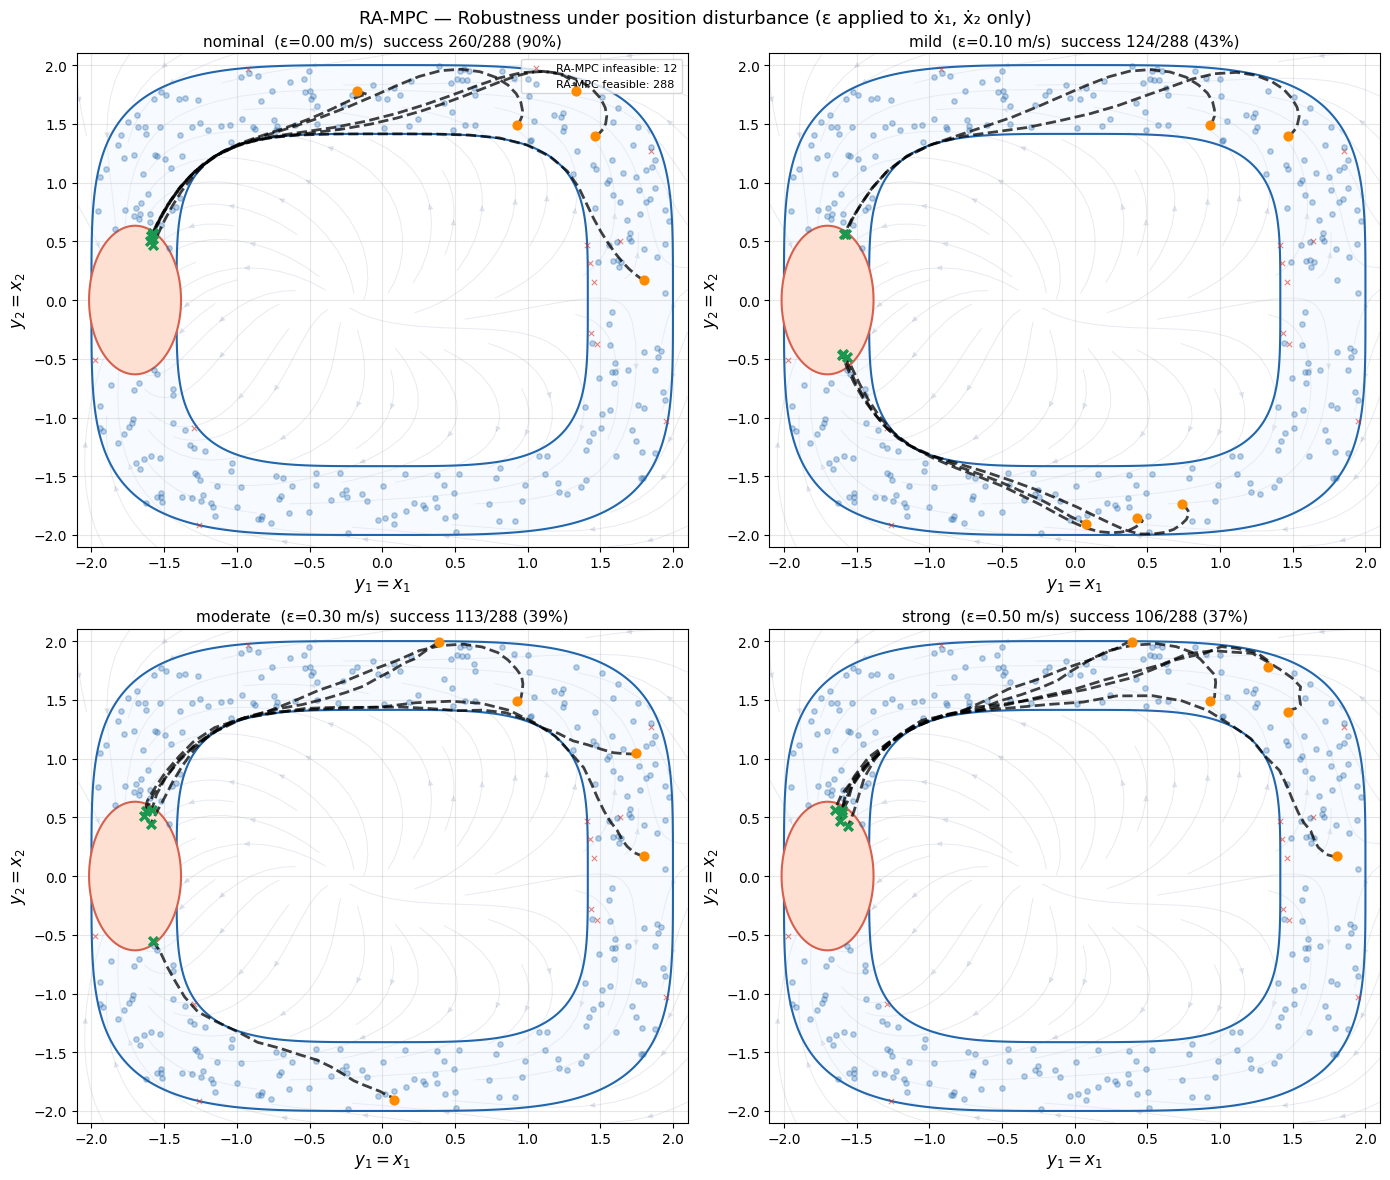

Phase portrait grid saved.


In [11]:
# ── Phase portraits — feasibility scatter + sample trajectories per level ──────
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('RA-MPC — Robustness under position disturbance (ε applied to ẋ₁, ẋ₂ only)',
             fontsize=13)

n_grid = 400
y1_g = np.linspace(-2.1, 2.1, n_grid); y2_g = np.linspace(-2.1, 2.1, n_grid)
Y1, Y2 = np.meshgrid(y1_g, y2_g)
Z_safe_y   = safe_set_y_func(Y1, Y2)
Z_target_y = target_set_y_func(Y1, Y2)

k1_func_lam = sp.lambdify([y1, y2], list(k1_opt), 'numpy')
n_vf = 30; y1_vf = np.linspace(-2.1, 2.1, n_vf); y2_vf = np.linspace(-2.1, 2.1, n_vf)
VF_Y1, VF_Y2 = np.meshgrid(y1_vf, y2_vf)
k1_vals = np.array(k1_func_lam(VF_Y1, VF_Y2)).squeeze()
U_k1, V_k1 = k1_vals[0], k1_vals[1]

# Feasibility scatter in position space (same for all panels)
y_feas_plot   = np.array(hx_func(*x_samples[:, mpc_feasible_idx])).reshape(2, -1)
y_infeas_plot = np.array(hx_func(*x_samples[:, mpc_infeasible_idx])).reshape(2, -1)

for ax, level_name in zip(axes.flat, level_order):
    eps_label = next(lv['eps'] for lv in LEVELS if lv['name'] == level_name)

    ax.streamplot(y1_vf, y2_vf, U_k1, V_k1, color=BetterColor.gray0(0.30),
                  linewidth=0.7, density=0.8, arrowsize=0.8, zorder=0)
    ax.contourf(Y1, Y2, Z_safe_y,   levels=[0, np.inf],  colors=['#e6f2ff'], alpha=0.3, zorder=1)
    ax.contour( Y1, Y2, Z_safe_y,   levels=[0], colors=['#2166ac'], linewidths=1.5, zorder=2)
    ax.contourf(Y1, Y2, Z_target_y, levels=[-np.inf, 0], colors=['#fee0d2'], alpha=1.0, zorder=3)
    ax.contour( Y1, Y2, Z_target_y, levels=[0], colors=['#d6604d'], linewidths=1.5, zorder=4)

    # Feasibility dots (original paper style)
    ax.scatter(y_infeas_plot[0], y_infeas_plot[1], s=15, color='#d73027', alpha=0.6,
               marker='x', linewidths=0.8,
               label=f'RA-MPC infeasible: {len(mpc_infeasible_idx)}', zorder=6)
    ax.scatter(y_feas_plot[0],  y_feas_plot[1],  s=15, color='#2166ac', alpha=0.30,
               marker='o',
               label=f'RA-MPC feasible: {len(mpc_feasible_idx)}', zorder=7)

    # Sample trajectories
    raw_lv = all_level_traj[level_name]
    shown  = 0
    for ts_i, xs_i, ys_i in raw_lv:
        phi_f = float(np.squeeze(target_set_x_func(*xs_i[-1])))
        if phi_f <= phi_tol and ts_i[-1] >= T_min and ts_i[-1] < T_max - 1e-6:
            ax.plot(ys_i[:, 0], ys_i[:, 1], 'k--', lw=2.0, alpha=0.75, zorder=10)
            ax.scatter(ys_i[0, 0],  ys_i[0, 1],  s=40, c=[BetterColor.orange3()],
                       marker='o', zorder=20)
            ax.scatter(ys_i[-1, 0], ys_i[-1, 1], s=40, c=[BetterColor.green0()],
                       marker='x', linewidths=2.5, zorder=20)
            shown += 1
            if shown >= 5: break

    n_ok  = sum(1 for r in all_rows if r['level'] == level_name and r['success'])
    n_tot = sum(1 for r in all_rows if r['level'] == level_name)
    ax.set_title(f'{level_name}  (ε={eps_label:.2f} m/s)  '
                 f'success {n_ok}/{n_tot} ({100*n_ok/n_tot:.0f}%)', fontsize=11)
    ax.set_xlabel('$y_1 = x_1$', fontsize=12)
    ax.set_ylabel('$y_2 = x_2$', fontsize=12)
    ax.grid(True, alpha=0.3)
    if level_name == 'nominal':
        ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('fig_robustness_phase_ra_mpc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Phase portrait grid saved.')

Saved robustness_results_ra_mpc.csv  (1152 rows)


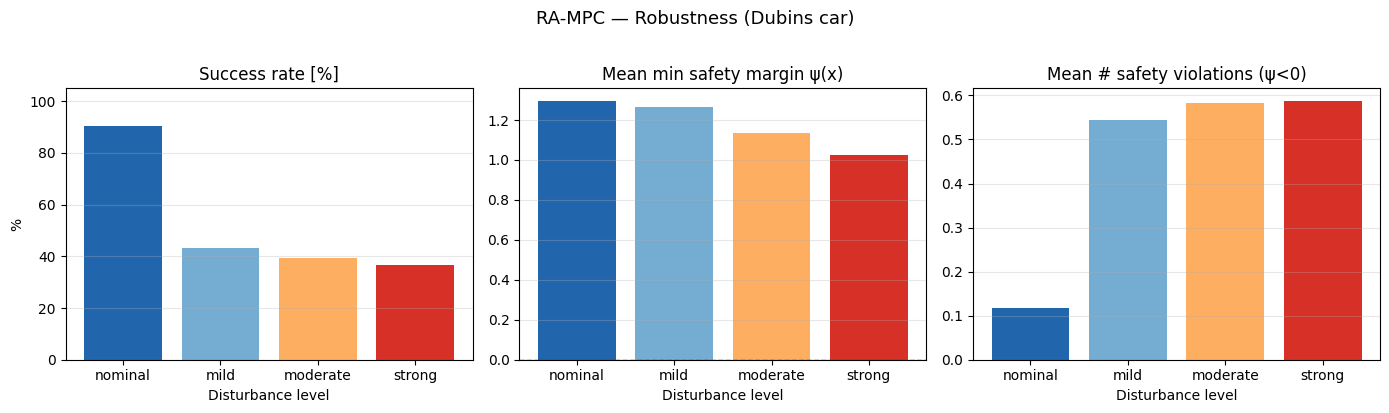


Summary:
          success_rate  mean_min_psi  mean_violations  mean_effort
level                                                             
nominal         90.278         1.294            0.118       25.908
mild            43.056         1.263            0.545       19.833
moderate        39.236         1.133            0.583       19.302
strong          36.806         1.025            0.587       18.914


In [12]:
df.to_csv('robustness_results_ra_mpc.csv', index=False)
print(f'Saved robustness_results_ra_mpc.csv  ({len(df)} rows)')

summary = df.groupby('level').agg(
    success_rate   =('success',            lambda x: 100*x.mean()),
    mean_min_psi   =('min_safety_margin',  'mean'),
    mean_violations=('n_safety_violations','mean'),
    mean_effort    =('control_effort',     'mean'),
).reindex(level_order)

colors = ['#2166ac','#74add1','#fdae61','#d73027']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].bar(level_order, summary['success_rate'],    color=colors)
axes[0].set_title('Success rate [%]'); axes[0].set_ylim(0,105); axes[0].set_ylabel('%')
axes[1].bar(level_order, summary['mean_min_psi'],    color=colors)
axes[1].axhline(0, color='red', lw=1, ls='--'); axes[1].set_title('Mean min safety margin \u03c8(x)')
axes[2].bar(level_order, summary['mean_violations'], color=colors)
axes[2].set_title('Mean # safety violations (\u03c8<0)')
for ax in axes: ax.set_xlabel('Disturbance level'); ax.grid(axis='y', alpha=0.3)
fig.suptitle('RA-MPC — Robustness (Dubins car)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig_robustness_ra_mpc.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSummary:')
print(summary.round(3).to_string())